<a href="https://colab.research.google.com/github/YESHASWINI-R/crop-recommendation-system/blob/main/Crop_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost
!pip install --upgrade pandas

# Import libraries

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from google.colab import files


In [ ]:

# Load kaggle.json
with open("kaggle.json") as f:
    kaggle_credentials = json.load(f)
os.environ["KAGGLE_USERNAME"] = kaggle_credentials["username"]
os.environ["KAGGLE_KEY"] = kaggle_credentials["key"]


In [ ]:
# Use Kaggle API to download dataset
!kaggle datasets download -d atharvaingle/crop-recommendation-dataset


Dataset URL: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
License(s): apache-2.0
  0% 0.00/63.7k [00:00<?, ?B/s]
100% 63.7k/63.7k [00:00<00:00, 170MB/s]


In [ ]:
# Use Kaggle API to download dataset
!kaggle datasets download -d atharvaingle/crop-recommendation-dataset


Dataset URL: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
License(s): apache-2.0
crop-recommendation-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile

with ZipFile("crop-recommendation-dataset.zip", "r") as zip_ref:
    zip_ref.extractall()  # Extracts into Colab's current directory

# Verify files
!ls


Crop_recommendation.csv		 drive	      sample_data
crop-recommendation-dataset.zip  kaggle.json


# EDA

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
Missing v

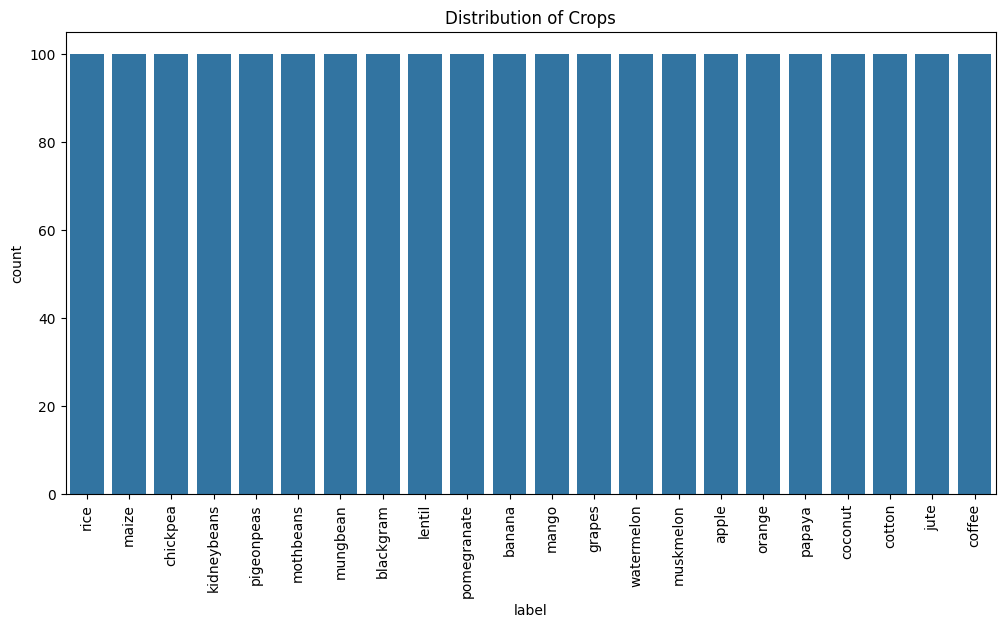

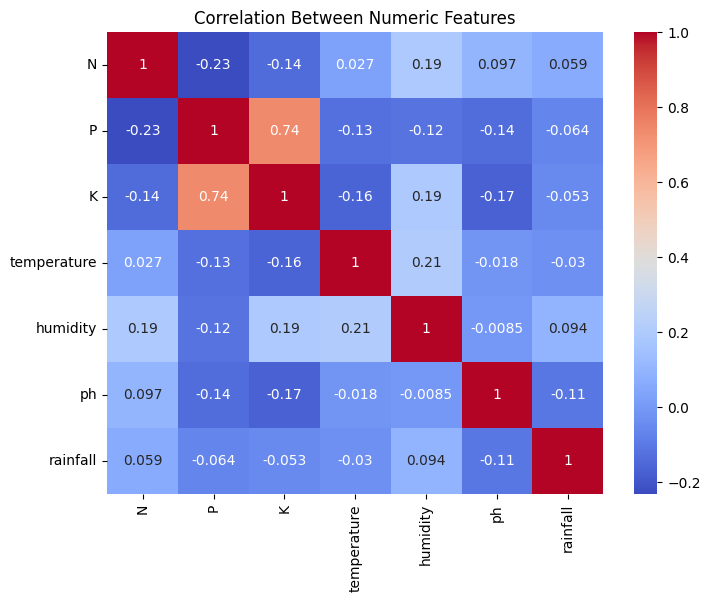

In [ ]:
# Check first few rows
print(df.head())

# Check data info and types
print(df.info())

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Check the distribution of the target column 'label'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Crops")
plt.show()

# Check correlation of numeric features only
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()


# Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode target column 'label'
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Features and target
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label_encoded']

# Split into training and test set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# RAndom Forest Classifier

Random Forest Accuracy: 0.9954545454545455
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00     

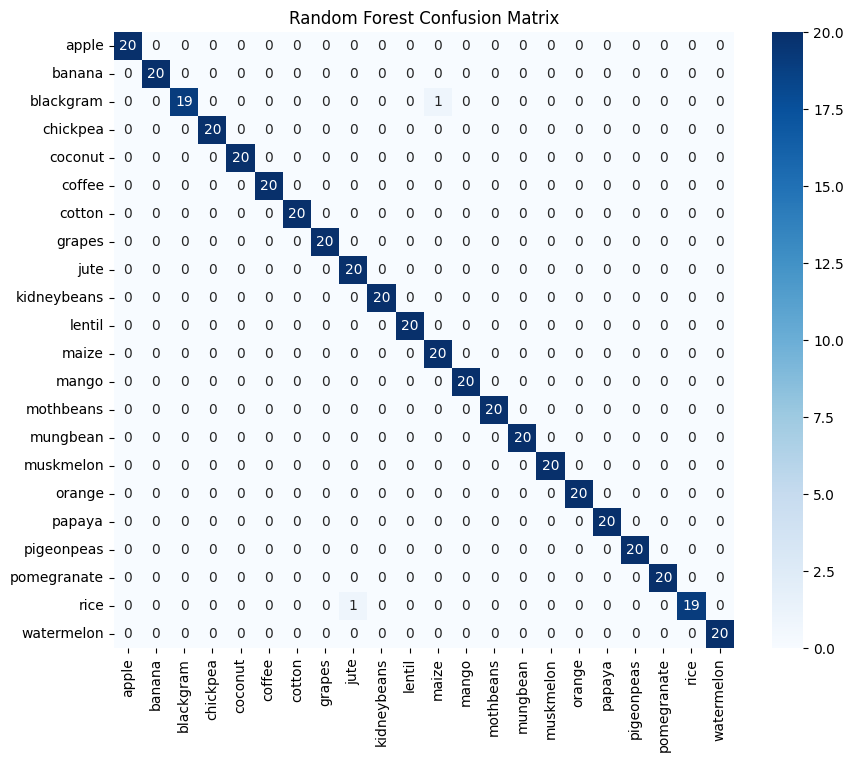

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Random Forest Confusion Matrix")
plt.show()


# XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:40:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9886363636363636
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.85      0.92        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.91      1.00      0.95        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00 

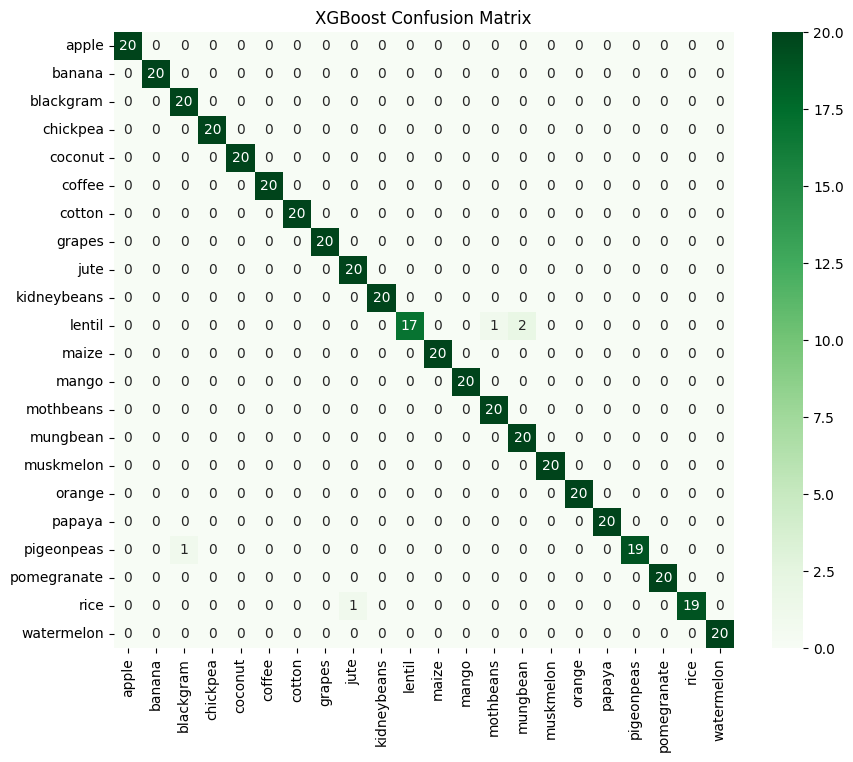

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=200, learning_rate=0.1, random_state=42,
    use_label_encoder=False, eval_metric='mlogloss'
)
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", acc_xgb)
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10,8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost Confusion Matrix")
plt.show()


In [ ]:
print(f"Random Forest Accuracy: {acc_rf}")
print(f"XGBoost Accuracy: {acc_xgb}")

best_model = rf_model if acc_rf > acc_xgb else xgb_model
print("Selected Best Model:", "Random Forest" if best_model==rf_model else "XGBoost")


Random Forest Accuracy: 0.9954545454545455
XGBoost Accuracy: 0.9886363636363636
Selected Best Model: Random Forest


# Save Model, Label Encoder, and Scaler

In [ ]:
import joblib
from google.colab import files

# Save objects
joblib.dump(best_model, 'crop_recommendation_model.pkl')
joblib.dump(le, 'crop_label_encoder.pkl')
joblib.dump(scaler, 'crop_scaler.pkl')

# Optional: download to local
files.download('crop_recommendation_model.pkl')
files.download('crop_label_encoder.pkl')
files.download('crop_scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# test Prediction

In [ ]:
# Example input: N=50, P=30, K=20, Temp=30.5, Humidity=80, pH=6.5, Rainfall=200
input_data = np.array([[50, 30, 20, 30.5, 80, 6.5, 200]])
input_scaled = scaler.transform(input_data)

pred_encoded = best_model.predict(input_scaled)
pred_crop = le.inverse_transform(pred_encoded)
print("Recommended Crop:", pred_crop[0])


Recommended Crop: coconut


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
